**References:**

- https://keras.io/examples/rl/ppo_cartpole/
- [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347)
- [OpenAI Spinning Up docs - PPO](https://spinningup.openai.com/en/latest/algorithms/ppo.html)
- [OpenAI Spinning Up Github - PPO](https://github.com/openai/spinningup/blob/master/spinup/algos/tf1/ppo/ppo.py)
- https://github.com/openai/gym/blob/master/gym/envs/classic_control/cartpole.py

In [4]:
import warnings

In [5]:
import os

os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


import tensorflow as tf
#from tf import keras as keras
import keras
from keras import layers

import numpy as np
import gym
import scipy.signal

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pickle

In [8]:
np.seterr(all="ignore")

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [9]:
import matplotlib, cv2
import matplotlib.pyplot as plt
import base64, io, os, time
import IPython, functools
#from tqdm import tqdm
import tensorflow_probability as tfp
import math
from typing import Optional
from gym import spaces, logger
from gym.utils import seeding

/usr/local/lib/python3.12/dist-packages/tensorflow_probability/python/__init__.py:57: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if (distutils.version.LooseVersion(tf.__version__) <
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
warnings.filterwarnings("ignore", message=".*Conversion of an array with ndim > 0 to a scalar.*")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [11]:
from numpy.linalg import matrix_power
from scipy.linalg import block_diag

## Functions and class

In [12]:
class CartPoleEnvCustomized(gym.Env):
    """
    ### Description
    This environment corresponds to the version of the cart-pole problem
    described by Barto, Sutton, and Anderson in ["Neuronlike Adaptive Elements That Can Solve Difficult Learning Control Problem"](https://ieeexplore.ieee.org/document/6313077).
    A pole is attached by an un-actuated joint to a cart, which moves along a
    frictionless track. The pendulum starts upright, and the goal is to prevent
    it from falling over by increasing and reducing the cart's velocity.
    ### Action Space
    The agent take a 1-element vector for actions.
    The action space is `(action)` in `[0, 1]`, where `action` is used to push
    the cart with a fixed amount of force:
    | Num | Action                 |
    |-----|------------------------|
    | 0   | Push cart to the left  |
    | 1   | Push cart to the right |
    Note: The amount the velocity is reduced or increased is not fixed as it depends on the angle the pole is pointing.
    This is because the center of gravity of the pole increases the amount of energy needed to move the cart underneath it
    ### Observation Space
    The observation is a `ndarray` with shape `(4,)` where the elements correspond to the following:
    | Num | Observation           | Min                  | Max                |
    |-----|-----------------------|----------------------|--------------------|
    | 0   | Cart Position         | -4.8*                 | 4.8*                |
    | 1   | Cart Velocity         | -Inf                 | Inf                |
    | 2   | Pole Angle            | ~ -0.418 rad (-24°)** | ~ 0.418 rad (24°)** |
    | 3   | Pole Angular Velocity | -Inf                 | Inf                |
    **Note:** above denotes the ranges of possible observations for each element, but in two cases this range exceeds the
    range of possible values in an un-terminated episode:
    - `*`: the cart x-position can be observed between `(-4.8, 4.8)`, but an episode terminates if the cart leaves the
    `(-2.4, 2.4)` range.
    - `**`: Similarly, the pole angle can be observed between  `(-.418, .418)` radians or precisely **±24°**, but an episode is
    terminated if the pole angle is outside the `(-.2095, .2095)` range or precisely **±12°**
    ### Rewards
    Reward is 1 for every step taken, including the termination step. The threshold is 475 for v1.
    ### Starting State
    All observations are assigned a uniform random value between (-0.05, 0.05)
    ### Episode Termination
    The episode terminates of one of the following occurs:
    1. Pole Angle is more than ±12°
    2. Cart Position is more than ±2.4 (center of the cart reaches the edge of the display)
    3. Episode length is greater than 500 (200 for v0)
    ### Arguments
    No additional arguments are currently supported.
    """

    metadata = {"render.modes": ["human", "rgb_array"], "video.frames_per_second": 50}

    def __init__(self):
        self.gravity = 9.8
        self.masscart = 1.0
        self.masspole = 0.1
        self.total_mass = self.masspole + self.masscart
        self.length = 0.5  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = 10.0
        self.dt = 0.02  # seconds between state updates
        self.kinematics_integrator = None # "euler","semi-implicit euler"


        # Angle at which to fail the episode
        self.theta_threshold_radians = 12 * 2 * math.pi / 360
        self.x_threshold = 2.4
        #self.i_threshold = self.force_mag / self.torque_const_Kt

        # Angle limit set to 2 * theta_threshold_radians so failing observation
        # is still within bounds.
        high = np.array(
            [
                self.x_threshold * 2,
                np.finfo(np.float32).max,
                self.theta_threshold_radians * 2,
                np.finfo(np.float32).max,
            ],
            dtype=np.float32,
        )

        self.action_space = spaces.Discrete(2)
        self.observation_space = spaces.Box(-high, high, dtype=np.float32)

        self.viewer = None
        self.state = None

        self.steps_beyond_done = None

        ### Customization changes ######
        self.DCMotor_radius = 0.15 #0.2 #### chnge actualy diameter and arm len for rotation
        self.NumIntegrationsSteps = 1
        self.MPC = ModelPredictCtrl()
        self.MPC.N = 60
        dt_prime = self.dt/self.NumIntegrationsSteps
        self.tau = dt_prime
        self.MPC.dt = dt_prime
        self.MPC.plant.tau1 = dt_prime
        self.MPC.ref_model.tau1 = dt_prime
        self.MPC.ConfigureMPCParams()
        self.wanted_torque = 0
        ####


    def step(self, action):
        err_msg = f"{action!r} ({type(action)}) invalid"
        assert self.action_space.contains(action), err_msg

        x, x_dot, theta, theta_dot = self.state
        force = +self.force_mag if action == 1 else -self.force_mag #+/-10N
        #wanted_torque_ret = self.wanted_torque #return old action
        torque_wanted = force*self.DCMotor_radius
        self.MPC.y_spf = torque_wanted
        beta_AF = 0.5
        torque_wanted =  (beta_AF)*self.wanted_torque+(1-beta_AF)*torque_wanted
        self.wanted_torque = torque_wanted
        self.MPC.y[0] = torque_wanted #self.MPC.y_spf #torque_wanted
        wanted_torque_ret = self.wanted_torque
        ### Customization changes #####
        for n in np.arange(start=0, stop=self.NumIntegrationsSteps, step=1):
          #w = x_dot/self.DCMotor_radius
          self.MPC.plant.thetadot =  x_dot/self.DCMotor_radius
          torque_actual = self.MPC.step()
          F = torque_actual/self.DCMotor_radius
          #F = torque_wanted/self.DCMotor_radius #ideal env
          ###

          costheta = math.cos(theta)
          sintheta = math.sin(theta)

          # For the interested reader:
          # https://coneural.org/florian/papers/05_cart_pole.pdf
          temp = (
              F + self.polemass_length * theta_dot ** 2 * sintheta
          ) / self.total_mass
          thetaacc = (self.gravity * sintheta - costheta * temp) / (
              self.length * (4.0 / 3.0 - self.masspole * costheta ** 2 / self.total_mass)
          )
          xacc = temp - self.polemass_length * thetaacc * costheta / self.total_mass

          if self.kinematics_integrator == "euler":
              x = x + self.tau * x_dot
              x_dot = x_dot + self.tau * xacc
              theta = theta + self.tau * theta_dot
              theta_dot = theta_dot + self.tau * thetaacc
          elif self.kinematics_integrator == "semi-implicit euler":
              x_dot = x_dot + self.tau * xacc
              x = x + self.tau * x_dot
              theta_dot = theta_dot + self.tau * thetaacc
              theta = theta + self.tau * theta_dot
          else: # trapz on velocities
              new_x_dot = x_dot + self.tau * xacc
              new_theta_dot = theta_dot + self.tau * thetaacc
              x = x + self.tau * (x_dot+new_x_dot)/2
              theta = theta + self.tau * (theta_dot+new_theta_dot)/2
              x_dot = new_x_dot+0
              theta_dot = new_theta_dot+0


        self.state = (x, x_dot, theta, theta_dot)

        done = bool(
            x < -self.x_threshold
            or x > self.x_threshold
            or theta < -self.theta_threshold_radians
            or theta > self.theta_threshold_radians
        )

        if not done: # if we inside the valid range
            reward = 1.0

        elif self.steps_beyond_done is None:
            # Pole just fell!
            self.steps_beyond_done = 0
            reward = 1.0

        else:
            if self.steps_beyond_done == 0:
                logger.warn(
                    "You are calling 'step()' even though this "
                    "environment has already returned done = True. You "
                    "should always call 'reset()' once you receive 'done = "
                    "True' -- any further steps are undefined behavior."
                )
            self.steps_beyond_done += 1
            reward = 0.0

        return np.array(self.state, dtype=np.float32), reward, done, {} ,wanted_torque_ret, torque_actual


    def reset(self, return_info = False, options = None):
        #super().reset(seed=seed)
        self.state = np.random.uniform(low=-0.05, high=0.05, size=(4,))

        self.steps_beyond_done = None

        ### reset MPC
        self.MPC.reset()
        self.MPC.plant.reset()
        self.MPC.ref_model.reset()
        self.wanted_torque = 0
        #

        if not return_info:
            return np.array(self.state, dtype=np.float32)
        else:
            return np.array(self.state, dtype=np.float32), {}

    def render(self, mode="human"):
        screen_width = 600
        screen_height = 400

        world_width = self.x_threshold * 2
        scale = screen_width / world_width
        carty = 100  # TOP OF CART
        polewidth = 10.0
        polelen = scale * (2 * self.length)
        cartwidth = 50.0
        cartheight = 30.0

        if self.viewer is None:
            #from gym.utils import pyglet_rendering
            from gym.envs.classic_control import rendering as pyglet_rendering

            self.viewer = pyglet_rendering.Viewer(screen_width, screen_height)
            l, r, t, b = -cartwidth / 2, cartwidth / 2, cartheight / 2, -cartheight / 2
            axleoffset = cartheight / 4.0
            cart = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            self.carttrans = pyglet_rendering.Transform()
            cart.add_attr(self.carttrans)
            self.viewer.add_geom(cart)
            l, r, t, b = (
                -polewidth / 2,
                polewidth / 2,
                polelen - polewidth / 2,
                -polewidth / 2,
            )
            pole = pyglet_rendering.FilledPolygon([(l, b), (l, t), (r, t), (r, b)])
            pole.set_color(0.8, 0.6, 0.4)
            self.poletrans = pyglet_rendering.Transform(translation=(0, axleoffset))
            pole.add_attr(self.poletrans)
            pole.add_attr(self.carttrans)
            self.viewer.add_geom(pole)
            self.axle = pyglet_rendering.make_circle(polewidth / 2)
            self.axle.add_attr(self.poletrans)
            self.axle.add_attr(self.carttrans)
            self.axle.set_color(0.5, 0.5, 0.8)
            self.viewer.add_geom(self.axle)
            self.track = pyglet_rendering.Line((0, carty), (screen_width, carty))
            self.track.set_color(0, 0, 0)
            self.viewer.add_geom(self.track)

            self._pole_geom = pole

        if self.state is None:
            return None

        # Edit the pole polygon vertex
        pole = self._pole_geom
        l, r, t, b = (
            -polewidth / 2,
            polewidth / 2,
            polelen - polewidth / 2,
            -polewidth / 2,
        )
        pole.v = [(l, b), (l, t), (r, t), (r, b)]

        x = self.state
        cartx = x[0] * scale + screen_width / 2.0  # MIDDLE OF CART
        self.carttrans.set_translation(cartx, carty)
        self.poletrans.set_rotation(-x[2])

        return self.viewer.render(return_rgb_array=mode == "rgb_array")

    def close(self):
        if self.viewer:
            self.viewer.close()
            self.viewer = None

In [13]:
class ElectricalDCMotorEnv():

  def __init__(self):
    self.Resistor_R = 1.0
    self.inductor_L = 0.1
    self.torque_const_Kt = 1.0
    self.bemf_const_Ke = 1.0
    self.tau1 = 0.05
    self.ZOH_mode = True
        #
    self.current = 0.0
    self.voltage_input = None
    self.thetadot = 0.0
    self.F = 0.0

  def step(self, u):
    voltage_BEMF = self.thetadot*self.bemf_const_Ke
    self.voltage_input = np.clip(u, -10, 10)

    f1 = self.torque_const_Kt*self.current
    if self.ZOH_mode:
      a = np.exp(-self.tau1*self.Resistor_R/self.inductor_L)
      self.current = a*self.current + (1-a)/self.Resistor_R*(u-voltage_BEMF)
    else:
      self.current += self.tau1*(self.voltage_input-voltage_BEMF-self.current*self.Resistor_R)/self.inductor_L
    f2 = self.torque_const_Kt*self.current
    self.F=f2 #f1 #f2 #(f1+f2)/2
    return self.F # return actual applied torque

  def reset(self):
    self.current = 0.0
    self.F = 0.0


In [14]:
class ReferenceModel():

  def __init__(self):
    self.tau1 = 0.05
    self.A_rm = np.array([[0]])
    self.B_rm = np.array([[0]])
    self.y_rm = np.array([[0]])

  def step(self, u):
    # TODO: complete
    #for _ in range(0,1):
    y_m_prev = self.y_rm+0
    self.y_rm = self.A_rm@self.y_rm + self.B_rm*u
    return self.y_rm #y_m_prev #self.y_rm

  def reset(self):
    self.y_rm = np.array([[0]])




In [15]:
class ModelPredictCtrl:

  def __init__(self,dt=0.01, N=60,
               a_sp = 1, b_sp = 0,
               R_resistor = 1, L_inductor = 0.1,
               k_t=1,k_w=1):
    self.plant = ElectricalDCMotorEnv()
    self.ref_model = ReferenceModel()
    self.dt = dt
    self.a_sp = a_sp
    self.b_sp = b_sp
    self.R_resistor = R_resistor
    self.L_inductor = L_inductor
    self.k_t = k_t
    self.k_w = k_w
    self.N=N
    self.A_pm = None
    self.B_pm = None
    self.A = None
    self.B = None
    self.Atilde = None
    self.Q1 = np.array([[1,-1]]) ####
    self.Q = None
    self.R = None
    self.y_spf = None
    self.K = None
    self.K_MPC = None
    self.y = np.array([[0],[0]])
    self.u = 0


  def ConfigureMPCParams(self):

    # Configure reference model
    A_sp = self.a_sp
    A_rm = np.array([[A_sp]])
    B_rm = np.array([[self.b_sp]])
    self.ref_model.A_rm = A_rm
    self.ref_model.B_rm = B_rm


    # Configure plant model
    dt = self.dt
    # note: self.dt and self.ref_model.tau1 aren't necessarily the same
    A_sp = self.a_sp
    A_pm = np.exp(-self.R_resistor/self.L_inductor*dt)
    B_pm = self.k_t*(1-A_pm)/self.R_resistor
    B = np.array([[self.b_sp],[B_pm]])
    self.A = np.array([[A_sp,0],[0,A_pm]])
    self.B = B


    # Confgure weight matrices Q & R and control gain K_mpc
    N = self.N
    A = self.A
    B = self.B
    B_shape_1 = B.shape[1]

    Atilde = 0
    for n in range(0,N):
      if n==0:
        Atilde = A*1
      else:
        Atilde = np.vstack((Atilde,matrix_power(A, n+1)))
    self.Atilde = Atilde

    Btilde = 0
    for i in range(0,N):
      if i==0:
        Btilde = B*1
      else:
        Btilde = np.hstack((Btilde,B*0))
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = matrix_power(A, i)@B
        elif i>=j:
          row = np.hstack((row,matrix_power(A, i-j)@B))
        else:
          row = np.hstack((row,i*0*B))
      Btilde = np.vstack((Btilde,row))

    Q1 = self.Q1
    Q1_N = Q1+0
    for n in range(1,N):
      Q1_N = block_diag(Q1_N,Q1)
    W_Q = 100*np.eye(N)
    W_Q[0,0] = 500
    Q = ((Q1_N.T)@(W_Q))@Q1_N#####
    self.Q = Q

    I=np.eye(B_shape_1)
    O=0*I

    R1 = 0
    for i in range(0,N):
      if i==0:
        R1 = I
      else:
        R1 = np.hstack((R1,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j:
          Mij = I
        elif i==j+1:
          Mij = -I
        else:
          Mij = O
        row = np.hstack((row,Mij))
      R1 = np.vstack((R1,row))

    R2 = 0
    for i in range(0,N):
      if i==0:
          R2 = I
      else:
          R2 = np.hstack((R2,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I
          continue
        else:
          Mij = I*(i==j)
        row = np.hstack((row,Mij))
      R2 = np.vstack((R2,row))

    R3 = 0
    for i in range(0,N):
      if i==0:
        R3 = I
      else:
        R3 = np.hstack((R3,O))
    row = 0
    for i in range(1,N):
      for j in range(0,N):
        if j==0:
          row = -I*(i==1)
          continue
        elif i==j+1:
          Mij = -I
        else:
          Mij = (i<=j)*I/(N-i)
        row = np.hstack((row,Mij))
      R3 = np.vstack((R3,row))

    W_R = 0.01*np.eye(N*B_shape_1)
    W_R[0,0]=0.2 #5
    R=0.334*R1+0.333*R2+0.333*R3
    R=(R.T)@(W_R)@(R)
    self.R=R

    BTQ = Btilde.T@Q
    BTQB= BTQ@Btilde
    K = -np.linalg.pinv(BTQB+R)@BTQ
    R0 = 0
    for i in range(0,N):
      if i==0:
          R0 = I
      else:
          R0 = np.hstack((R0,O))
    self.K = R0@K
    self.K_MPC = self.K@Atilde
    #self.Atilde = Atilde

  def computeCtrlInput(self, y):#, w):
    self.u = (self.K_MPC@y).item()
    self.u = np.clip(self.u, -10, 10)
    return self.u

  def step(self):
    #self.y[0] = y_sp0
    u = self.computeCtrlInput(self.y)#, self.plant.thetadot)
    self.u = u#+1*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_rm = self.ref_model.step(self.u)#(u)
    self.u = u+self.k_w*self.plant.thetadot
    self.u = np.clip(self.u, -10, 10)
    y_pm = self.plant.step(self.u)
    self.y = np.vstack((y_rm,y_pm))
    return self.y[1].item()

  def reset(self):
    self.y = np.array([[0],[0]])
    self.u = 0




In [16]:
env = CartPoleEnvCustomized()

In [17]:
print("Sample Time: dt= ", env.dt)
print("Num Integrations Steps: N= ", env.NumIntegrationsSteps)
print("Integration Time: dt/N=", env.dt/env.NumIntegrationsSteps)


Sample Time: dt=  0.02
Num Integrations Steps: N=  1
Integration Time: dt/N= 0.02


In [18]:
print("K_MPC= ", env.MPC.K_MPC)

K_MPC=  [[ 5.4295893  -4.44155325]]


In [19]:

def discounted_cumulative_sums(x, discount):
    # Discounted cumulative sums of vectors for computing rewards-to-go and advantage estimates
    return scipy.signal.lfilter([1], [1, float(-discount)], x[::-1], axis=0)[::-1]


class Buffer:
    # Buffer for storing trajectories
    def __init__(self, observation_dimensions, size, gamma=0.99, lam=0.95):
        # Buffer initialization
        self.observation_buffer = np.zeros(
            (size, observation_dimensions), dtype=np.float32
        )
        self.action_buffer = np.zeros(size, dtype=np.int32)
        self.advantage_buffer = np.zeros(size, dtype=np.float32)
        self.reward_buffer = np.zeros(size, dtype=np.float32)
        self.return_buffer = np.zeros(size, dtype=np.float32)
        self.value_buffer = np.zeros(size, dtype=np.float32)
        self.logprobability_buffer = np.zeros(size, dtype=np.float32)
        self.gamma, self.lam = gamma, lam
        self.pointer, self.trajectory_start_index = 0, 0

    def store(self, observation, action, reward, value, logprobability):
        # Append one step of agent-environment interaction
        self.observation_buffer[self.pointer] = observation
        self.action_buffer[self.pointer] = action
        self.reward_buffer[self.pointer] = reward
        self.value_buffer[self.pointer] = value
        self.logprobability_buffer[self.pointer] = logprobability
        self.pointer += 1

    def finish_trajectory(self, last_value=0):
        # Finish the trajectory by computing advantage estimates and rewards-to-go
        path_slice = slice(self.trajectory_start_index, self.pointer)
        rewards = np.append(self.reward_buffer[path_slice], last_value)
        values = np.append(self.value_buffer[path_slice], last_value)

        deltas = rewards[:-1] + self.gamma * values[1:] - values[:-1]

        self.advantage_buffer[path_slice] = discounted_cumulative_sums(
            deltas, self.gamma * self.lam
        )
        self.return_buffer[path_slice] = discounted_cumulative_sums(
            rewards, self.gamma
        )[:-1]

        self.trajectory_start_index = self.pointer

    def get(self):
        # Get all data of the buffer and normalize the advantages
        self.pointer, self.trajectory_start_index = 0, 0
        advantage_mean, advantage_std = (
            np.mean(self.advantage_buffer),
            np.std(self.advantage_buffer),
        )
        self.advantage_buffer = (self.advantage_buffer - advantage_mean) / advantage_std
        return (
            self.observation_buffer,
            self.action_buffer,
            self.advantage_buffer,
            self.return_buffer,
            self.logprobability_buffer,
        )

#output_activation=None
def mlp(x, sizes, activation=keras.activations.tanh,
        output_activation=None):
    # Build a feedforward neural network
    for size in sizes[:-1]:
        x = layers.Dense(units=size, activation=activation)(x)
    return layers.Dense(units=sizes[-1], activation=output_activation)(x)



def logprobabilities(logits, a):
    # Compute the log-probabilities of taking actions a by using the logits (i.e. the output of the actor)
    logprobabilities_all = keras.ops.log_softmax(logits)
    logprobability = keras.ops.sum(
        keras.ops.one_hot(a, num_actions) * logprobabilities_all, axis=1
    )
    return logprobability


seed_generator = keras.random.SeedGenerator(1337)


# Sample action from actor
@tf.function
def sample_action(observation):
    logits = actor(observation)
    action = keras.ops.squeeze(
        keras.random.categorical(logits, 1, seed=seed_generator), axis=1
    )
    return logits, action


# Train the policy by maxizing the PPO-Clip objective
@tf.function
def train_policy(
    observation_buffer, action_buffer, logprobability_buffer, advantage_buffer
):
    with tf.GradientTape() as tape:  # Record operations for automatic differentiation.
        ratio = keras.ops.exp(
            logprobabilities(actor(observation_buffer), action_buffer)
            - logprobability_buffer
        )
        min_advantage = keras.ops.where(
            advantage_buffer > 0,
            (1 + clip_ratio) * advantage_buffer,
            (1 - clip_ratio) * advantage_buffer,
        )

        policy_loss = -keras.ops.mean(
            keras.ops.minimum(ratio * advantage_buffer, min_advantage)
        )
    policy_grads = tape.gradient(policy_loss, actor.trainable_variables)
    policy_optimizer.apply_gradients(zip(policy_grads, actor.trainable_variables))

    kl = keras.ops.mean(
        logprobability_buffer
        - logprobabilities(actor(observation_buffer), action_buffer)
    )
    kl = keras.ops.sum(kl)
    return kl


# Train the value function by regression on mean-squared error
@tf.function
def train_value_function(observation_buffer, return_buffer):
    with tf.GradientTape() as tape:  # Record operations for automatic differentiation.
        value_loss = keras.ops.mean((return_buffer - critic(observation_buffer)) ** 2)
    value_grads = tape.gradient(value_loss, critic.trainable_variables)
    value_optimizer.apply_gradients(zip(value_grads, critic.trainable_variables))


## Hyperparameters

In [20]:
# Hyperparameters of the PPO algorithm
steps_per_epoch = 4000
epochs = 100 #60 # 40 #30
steps_per_episode_goal = 500
episodes_max = 2500 #3000
gamma = 0.99
clip_ratio = 0.2
policy_learning_rate = 3e-4
value_function_learning_rate = 1e-3
train_policy_iterations = 80
train_value_iterations = 80
lam = 0.97
target_kl = 0.01
hidden_sizes = (64, 64)

# True if you want to render the environment
render = False

## Initializations

In [21]:
# Initialize the environment and get the dimensionality of the
# observation space and the number of possible actions
env = CartPoleEnvCustomized()
observation_dimensions = env.observation_space.shape[0]
num_actions = env.action_space.n

# Initialize the buffer
buffer = Buffer(observation_dimensions, steps_per_epoch)

# Initialize the actor and the critic as keras models
observation_input = keras.Input(shape=(observation_dimensions,), dtype="float32")
logits = mlp(observation_input, list(hidden_sizes) + [num_actions])
actor = keras.Model(inputs=observation_input, outputs=logits)
value = keras.ops.squeeze(mlp(observation_input, list(hidden_sizes) + [1]), axis=1)
critic = keras.Model(inputs=observation_input, outputs=value)

# Initialize the policy and the value function optimizers
policy_optimizer = keras.optimizers.Adam(learning_rate=policy_learning_rate)
value_optimizer = keras.optimizers.Adam(learning_rate=value_function_learning_rate)

# Initialize the observation, episode return and episode length
#observation, _ = env.reset()
observation = env.reset()
episode_return, episode_length = 0, 0

In [22]:
#actor.summary()

In [23]:
#critic.summary()

## Train

In [24]:
avg_reward_list = []
acc_ep_reward_list = []

episode = 0
epoch = 0
# Iterate over the number of epochs/episodes
#while (epoch < epochs) and (episode < episodes_max):
while(episode < episodes_max):
    print(f"Epoch: {epoch}")
    # Initialize the sum of the returns, lengths and number of episodes for each epoch
    episode_return = 0.0
    t = 0
    # Iterate over the steps of each epoch
    #while (t < steps_per_epoch):
    while (t < steps_per_epoch) and (episode < episodes_max):
        if render:
            env.render()

        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        x_obs = observation_new[0]
        reward_learn= reward*(x_obs>-0.1 and x_obs<0.1)
        episode_return += reward

        # Get the value and log-probability of the action
        value_t = critic(observation)
        logprobability_t = logprobabilities(logits, action)
        # Store obs, act, rew, v_t, logp_pi_t
        buffer.store(observation, action, reward_learn, value_t, logprobability_t)
        # Update the observation
        observation = observation_new

        # Finish trajectory if reached to a terminal state
        terminal = done
        if terminal or (t == steps_per_epoch - 1) or ((t+1)%steps_per_episode_goal==0):
            #print(f"Episode: {episode}; Acc. Reward: {episode_return:.2f}")
            acc_ep_reward_list.append(episode_return)
            avg_return = round(np.mean(acc_ep_reward_list[-40:]))
            avg_reward_list.append(avg_return)
            episode_return = 0.0
            episode += 1
        #observation, _ = env.reset()
        if terminal or (t == steps_per_epoch - 1):# not necessarily (t+1)%steps_per_episode_goal==0
            last_value = 0 if done else critic(observation.reshape(1, -1))
            buffer.finish_trajectory(last_value)
            observation = env.reset()
            print(f"Episode: {episode}; Acc. Reward: {avg_return:.1f}; Pole fell: {terminal}")
            #acc_ep_reward_list.append(episode_return)
            #print(f"Episode: {episode} ;Acc. Reward: {episode_return:.1f}")
            #episode_return = 0.0
        t+=1
        #if episode >= episodes_max:
        #  break

    # Get values from the buffer
    (
        observation_buffer,
        action_buffer,
        advantage_buffer,
        return_buffer,
        logprobability_buffer,
    ) = buffer.get()

    # Update the policy and implement early stopping using KL divergence
    for _ in range(train_policy_iterations):
        kl = train_policy(
            observation_buffer, action_buffer, logprobability_buffer, advantage_buffer
        )
        if kl > 1.5 * target_kl:
            # Early Stopping
            break

    # Update the value function
    for _ in range(train_value_iterations):
        train_value_function(observation_buffer, return_buffer)
    epoch+=1


Epoch: 0
Episode: 1; Acc. Reward: 29.0; Pole fell: True
Episode: 2; Acc. Reward: 22.0; Pole fell: True
Episode: 3; Acc. Reward: 21.0; Pole fell: True
Episode: 4; Acc. Reward: 21.0; Pole fell: True
Episode: 5; Acc. Reward: 20.0; Pole fell: True
Episode: 6; Acc. Reward: 19.0; Pole fell: True
Episode: 7; Acc. Reward: 18.0; Pole fell: True
Episode: 8; Acc. Reward: 18.0; Pole fell: True
Episode: 9; Acc. Reward: 18.0; Pole fell: True
Episode: 10; Acc. Reward: 20.0; Pole fell: True
Episode: 11; Acc. Reward: 20.0; Pole fell: True
Episode: 12; Acc. Reward: 20.0; Pole fell: True
Episode: 13; Acc. Reward: 21.0; Pole fell: True
Episode: 14; Acc. Reward: 20.0; Pole fell: True
Episode: 15; Acc. Reward: 22.0; Pole fell: True
Episode: 16; Acc. Reward: 22.0; Pole fell: True
Episode: 17; Acc. Reward: 21.0; Pole fell: True
Episode: 18; Acc. Reward: 21.0; Pole fell: True
Episode: 19; Acc. Reward: 21.0; Pole fell: True
Episode: 20; Acc. Reward: 20.0; Pole fell: True
Episode: 21; Acc. Reward: 20.0; Pole fel

In [25]:
total_episodes_test = 100
best_score = -1000
ep_reward_list_test = []

In [26]:
print('Test')
for ep in range(total_episodes_test):
    observation = env.reset()
    save_observation_temp = [observation]
    save_wanted_torque_temp = [0.0]
    save_actual_torque_temp = [0.0]
    save_sp_torque_temp = [0.0]
    save_ctrl_voltage_temp = [0.0]
    done=False
    t=0
    episodic_reward = 0
    while not done and t<steps_per_episode_goal:
        # using our observation, choose an action and take it in the environment
        # Get the logits, action, and take one step in the environment
        observation = observation.reshape(1, -1)
        logits, action = sample_action(observation)
        #observation_new, reward, done, _, _ = env.step(action[0].numpy())
        observation_new, reward, done, _ ,torque_wanted, torque_actual= env.step(action[0].numpy().item())
        episodic_reward += reward
        observation = observation_new
        save_observation_temp.append(observation)
        save_wanted_torque_temp.append(torque_wanted)
        save_actual_torque_temp.append(torque_actual)
        save_sp_torque_temp.append(env.MPC.y_spf)
        save_ctrl_voltage_temp[-1]=env.MPC.plant.voltage_input
        save_ctrl_voltage_temp.append(0.0)
        t+=1

    # get best score and update save data
    #save_ctrl_voltage_temp.append(env.DCMotorModel.voltage_input)
    print(f"Episode: {ep}; Acc. Reward: {episodic_reward:.1f}; Pole fell: {done}")
    if best_score<episodic_reward:
        save_observation = list(save_observation_temp)
        save_wanted_torque = list(save_wanted_torque_temp)
        save_actual_torque = list(save_actual_torque_temp)
        save_ctrl_voltage = list(save_ctrl_voltage_temp)
        save_sp_torque = list(save_sp_torque_temp)
        best_score = episodic_reward
    ep_reward_list_test.append(episodic_reward)



Test
Episode: 0; Acc. Reward: 500.0; Pole fell: False
Episode: 1; Acc. Reward: 500.0; Pole fell: False
Episode: 2; Acc. Reward: 500.0; Pole fell: False
Episode: 3; Acc. Reward: 500.0; Pole fell: False
Episode: 4; Acc. Reward: 500.0; Pole fell: False
Episode: 5; Acc. Reward: 500.0; Pole fell: False
Episode: 6; Acc. Reward: 500.0; Pole fell: False
Episode: 7; Acc. Reward: 500.0; Pole fell: False
Episode: 8; Acc. Reward: 500.0; Pole fell: False
Episode: 9; Acc. Reward: 500.0; Pole fell: False
Episode: 10; Acc. Reward: 500.0; Pole fell: False
Episode: 11; Acc. Reward: 500.0; Pole fell: False
Episode: 12; Acc. Reward: 500.0; Pole fell: False
Episode: 13; Acc. Reward: 500.0; Pole fell: False
Episode: 14; Acc. Reward: 500.0; Pole fell: False
Episode: 15; Acc. Reward: 500.0; Pole fell: False
Episode: 16; Acc. Reward: 500.0; Pole fell: False
Episode: 17; Acc. Reward: 500.0; Pole fell: False
Episode: 18; Acc. Reward: 500.0; Pole fell: False
Episode: 19; Acc. Reward: 500.0; Pole fell: False
Episo

In [27]:
save_observation_temp = None
save_observation_temp = None
save_wanted_torque_temp = None
save_actual_torque_temp = None
save_sp_torque_temp = None
save_ctrl_voltage_temp = None

In [28]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Cartpole/'

In [29]:
# Create a dictionary of variables you want to save
variables_to_save = {
    'avg_reward_list': avg_reward_list,
    'acc_ep_reward_list': acc_ep_reward_list,
    'save_observation': save_observation,
    'save_wanted_torque': save_wanted_torque,
    'save_actual_torque': save_actual_torque,
    'save_ctrl_voltage': save_ctrl_voltage,
    'ep_reward_list_test': ep_reward_list_test,
    'save_sp_torque': save_sp_torque
}

In [30]:
actor.save(path+"cartple_actor.keras")
critic.save(path+"cartple_critic.keras")

In [31]:
with open(path+'Cartpole.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)
print(f"All variables saved to {path+'Cartpole.pkl'}")

All variables saved to /content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Cartpole/Cartpole.pkl


In [32]:
path = '/content/drive/MyDrive/Colab Notebooks/codes/MPC/save_data/Cartpole/'

In [33]:
# Open the file in read-binary mode and load the dictionary
with open(path+'Cartpole.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access the loaded variables
avg_reward_list = loaded_variables['avg_reward_list']
acc_ep_reward_list = loaded_variables['acc_ep_reward_list']
save_observation = loaded_variables['save_observation']
save_wanted_torque = loaded_variables['save_wanted_torque']
save_actual_torque = loaded_variables['save_actual_torque']
save_ctrl_voltage = loaded_variables['save_ctrl_voltage']
ep_reward_list_test = loaded_variables['ep_reward_list_test']
save_sp_torque = loaded_variables['save_sp_torque']

In [34]:
actor = keras.models.load_model(path+"cartple_actor.keras")
critic = keras.models.load_model(path+"cartple_critic.keras")

In [35]:
plt.rc('text.latex', preamble=r'\usepackage{amsmath,amssymb,amsfonts}')
#plt.rcParams["text.usetex"]=False
#plt.rcParams["font.family"] = "sans-serif"
#plt.rcParams["font.family"] = "serif"
#plt.rcParams['mathtext.fontset'] = 'cm'
#plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'

In [36]:
low_bound_reward_list = 0
up_bound_reward_list= 500
print("low_bound_reward_list=",low_bound_reward_list)
print("up_bound_reward_list=",up_bound_reward_list)

low_bound_reward_list= 0
up_bound_reward_list= 500


In [37]:
def unnorm_to_norm(x):
  y = (x-low_bound_reward_list)/(up_bound_reward_list-low_bound_reward_list)
  return y

In [38]:
def norm_to_unnorm(y):
  x=y*(up_bound_reward_list-low_bound_reward_list)+low_bound_reward_list
  return x

In [39]:
norm_reward_list = np.array(avg_reward_list)
#norm_reward_list = (norm_reward_list/abs(norm_reward_list.min())+1)*100
min_norm_reward_list = 0
max_norm_reward_list=500
norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)

In [40]:
norm_reward_list = np.array(avg_reward_list)
#norm_reward_list = (norm_reward_list-min_norm_reward_list)/(max_norm_reward_list-min_norm_reward_list)
norm_reward_list = unnorm_to_norm(norm_reward_list)

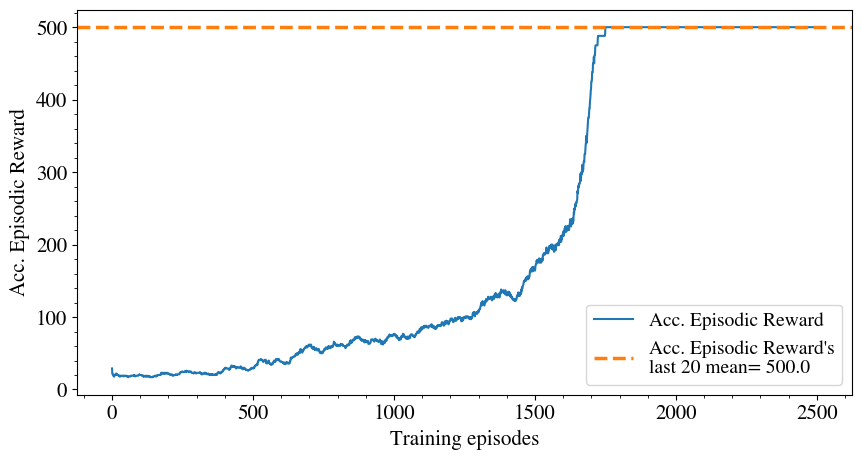

In [41]:
# Plotting graph
# Episodes versus Acc. Rewards
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(avg_reward_list, label = "Acc. Episodic Reward",color="C0",linewidth = 1.5)
plt.axhline(y=np.array(avg_reward_list)[-20:-1].mean(), linestyle='--',
            label = "Acc. Episodic Reward's\nlast 20 mean= "+f"{np.array(avg_reward_list)[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.minorticks_on()
plt.xlabel("Training episodes")
plt.ylabel("Acc. Episodic Reward")
#plt.grid()
plt.legend(fontsize=14)
plt.show()

In [42]:
print("Acc. Episodic Reward's last 20 mean=")
print(np.array(avg_reward_list)[-20:-1].mean())

Acc. Episodic Reward's last 20 mean=
500.0


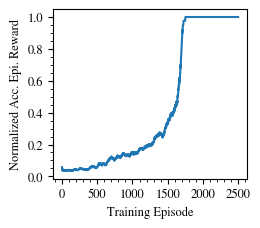

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [43]:
# Episodes versus Avg. Rewards

font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.5)
f.set_figheight(2.2)
plt.plot(norm_reward_list, label = "Normalized Acc. Epi. Reward",color="C0",linewidth = 1.5)
#plt.axhline(y=norm_reward_list[-20:-1].mean(), linestyle='--',
#            label = "Normalized Acc. Episodic Reward's last 20 mean= "+f"{norm_reward_list[-20:-1].mean():.1f}",color="C1",linewidth = 2.5)
plt.xlabel("Training Episode")
plt.ylabel("Normalized Acc. Epi. Reward")
#plt.grid()
#plt.legend()
plt.xticks(np.arange(0, 2501, 500))
#plt.yticks(np.arange(0.0, 1.1, 0.1))
plt.minorticks_on()
plt.savefig(path+"Cartpole_Acc_Reward_vs_Episode.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [44]:
print("Normalized Acc. Episodic Reward's last 20 mean=")
print(norm_reward_list[-20:-1].mean())

Normalized Acc. Episodic Reward's last 20 mean=
1.0


In [45]:
# Test Histogram
norm_ep_reward_list_test = np.array(ep_reward_list_test)
norm_ep_reward_list_test = unnorm_to_norm(norm_ep_reward_list_test)
print(norm_ep_reward_list_test.max())
print(norm_ep_reward_list_test.min())
min_bin = np.floor(norm_ep_reward_list_test.min()*100)/100
print(min_bin)

1.0
0.062
0.06


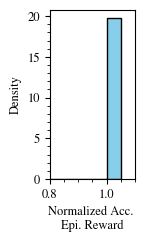

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [46]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(1.1)
f.set_figheight(2.2)
data_rewards = np.array(norm_ep_reward_list_test)
density_True = True
plt.hist(data_rewards, bins=np.arange(0,1.1,0.05), density=density_True ,color='skyblue', edgecolor='black')
plt.xlabel('Normalized Acc. \nEpi. Reward')
ylabel='Density'if density_True else 'Frequency'
plt.ylabel(ylabel)
#plt.xticks(np.arange(0.5,1.001,0.01))
plt.minorticks_on()
plt.xlim((0.8,1.1))
plt.savefig(path+"Cartpole_Acc_Reward_vs_Episode_Test_Hist.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [47]:
print("Test Normalized Acc Episodic Reward's Results:")
print(f"Unnormalized: max={norm_to_unnorm(data_rewards).max():.3f} ,mean={norm_to_unnorm(data_rewards).mean():.3f}, std={norm_to_unnorm(data_rewards).std():.3f}")
print(f"Normalized:   max={data_rewards.max():.3e} ,mean={data_rewards.mean():.3e}, std={data_rewards.std():.3e}")

Test Normalized Acc Episodic Reward's Results:
Unnormalized: max=500.000 ,mean=495.310, std=46.665
Normalized:   max=1.000e+00 ,mean=9.906e-01, std=9.333e-02


In [48]:
dt=env.dt

In [49]:
dt

0.02

In [50]:
time_= np.linspace(start = 0, stop = len(save_wanted_torque)* dt,
                   num=len(save_wanted_torque) )

In [51]:
sign_error = np.sign(np.array(save_wanted_torque)) - np.sign(np.array(save_actual_torque))
e_ry = np.array(save_wanted_torque) - np.array(save_actual_torque) ### add
force_error_max = np.max(np.abs(e_ry))
mean_std=f'(mean,std)=({e_ry.mean():.2e}, {e_ry.std():.2e})'

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_466/1000434111.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_, save_actual_torque , ':',label = "$y^{\mathrm{pm}}=a^{actual}$"+"\nfrom DC motor plant",color="red",linewidth = 4)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.12/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - u

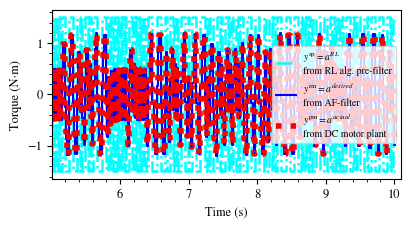

In [52]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(4.5)
f.set_figheight(2.2)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)
poly_fit = np.polynomial.polynomial.Polynomial.fit(x=time_[2:],y=e_ry[2:],deg=1,symbol='t')

plt.step(time_, save_sp_torque ,label = r"$y^{\mathrm{sp}}=a^{RL}$"+"\nfrom RL alg. pre-filter",color="cyan",linestyle='-.',linewidth = 1.8)
plt.step(time_, save_wanted_torque ,label = r"$y^{\mathrm{rm}}=a^{desired}$"+"\nfrom AF-filter",color="blue",linewidth = 1.5)
plt.step(time_, save_actual_torque , ':',label = "$y^{\mathrm{pm}}=a^{actual}$"+"\nfrom DC motor plant",color="red",linewidth = 4)
#plt.step(time_, e_ry,"--" ,label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$"+f":\n t≥"+str(2*dt)+"⇒"+"mean="+f'{e_ry[2:].mean():.4e}'+",\n std="+f'{e_ry[2:].std():.4e}'+", rms="+f'{np.sqrt((e_ry[2:]**2).mean()):.4e}'
#,color="black",linewidth = 2)
#plt.step(time_, e_ry ,label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 2)
#plt.axhline(y=e_ry.mean(), color="green",linewidth = 4, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.mean():.4e}')
#plt.axhline(y=np.sqrt((e_ry**2).mean()), color="black",linewidth = 4, linestyle='--', label='RMS($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{np.sqrt((e_ry**2).mean()):.4e}')
#plt.axhline(y=e_ry.std(), color="cyan",linewidth = 3, linestyle=(0, (3, 1, 1, 1)), label='STD($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.std():.4e}')


plt.xlabel('Time (s)')
plt.ylabel('Torque (N⋅m)')
plt.legend(fontsize=7)
#plt.legend(fontsize=10,bbox_to_anchor=(1.05, 1.0), loc='upper left')
#plt.legend(fontsize=13,loc='upper center', bbox_to_anchor=(0.5, -0.22),ncol=2)
#plt.grid()
plt.xlim((5.01,10.1))
plt.minorticks_on()
plt.savefig(path+"Cartpole_Torque_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [53]:
print("for t≥"+str(2*dt)+",n≥2:")
print('error≈',poly_fit)
print("mean=", f'{e_ry[2:].mean():.4e}')
print("std=", f'{e_ry[2:].std():.4e}')
print("rms=",f'{np.sqrt((e_ry[2:]**2).mean()):.4e}')
print("mae=",f'{np.abs(e_ry[2:]).mean():.4e}')

for t≥0.04,n≥2:
error≈ -3.24212371e-05 - (9.39403848e-05)·(-1.00803213 + 0.20040241t)
mean= -3.2421e-05
std= 1.3670e-02
rms= 1.3670e-02
mae= 1.3137e-02


<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:11: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_466/3224808089.py:11: SyntaxWarning: invalid escape sequence '\m'
  plt.step(time_[2:], e_ry[2:], '--',label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 1.5)
/tmp/ipykernel_466/3224808089.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.axhline(y=e_ry[2:].mean(), color="green",linewidth = 3, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry[2:].mean():.4e}')


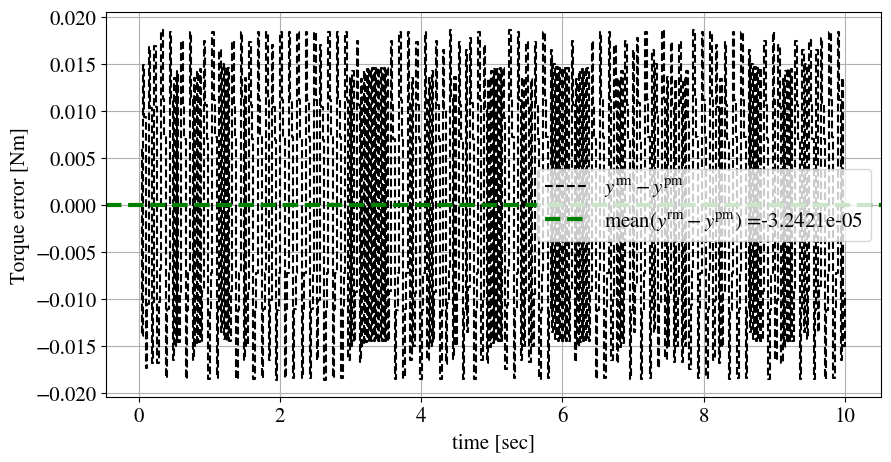

In [54]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

e_ry=np.array(save_wanted_torque)-np.array(save_actual_torque)


plt.step(time_[2:], e_ry[2:], '--',label = "$y^{\mathrm{rm}}-y^{\mathrm{pm}}$ ",color="black",linewidth = 1.5)
plt.axhline(y=e_ry[2:].mean(), color="green",linewidth = 3, linestyle='--', label='mean($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry[2:].mean():.4e}')
#plt.axhline(y=np.sqrt((e_ry**2).mean()), color="black",linewidth = 4, linestyle='--', label='RMS($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{np.sqrt((e_ry**2).mean()):.4e}')
#plt.axhline(y=e_ry.std(), color="cyan",linewidth = 3, linestyle=(0, (3, 1, 1, 1)), label='STD($y^{\mathrm{rm}}-y^{\mathrm{pm}}$) =' +f'{e_ry.std():.4e}')

plt.xlabel("time [sec]")
plt.ylabel("Torque error [Nm]")
plt.legend(fontsize=15)
#plt.legend(fontsize=10,bbox_to_anchor=(1.05, 1.0), loc='upper left')
plt.grid()
plt.show()

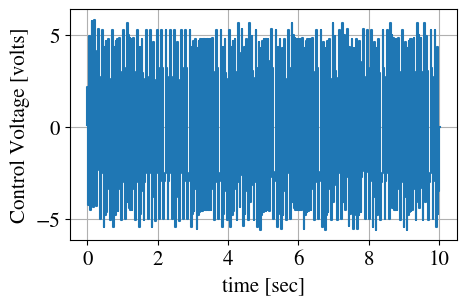

In [55]:
font = {'size': 15}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(5)
f.set_figheight(3)

#time_u = np.linspace(start = 0, stop = len(save_ctrl_voltage)* dt,num=len(save_ctrl_voltage) )

plt.step(time_, save_ctrl_voltage)
plt.xlabel("time [sec]")
plt.ylabel("Control Voltage [volts]")
plt.grid()
plt.show()

In [56]:
# distribution to 4 observation parameters

position = []
velocity = []
angle = []
angular_velocity = []
for observ in save_observation:
  for index,value in enumerate(observ):
    if index == 0:
      position.append(value)
    if index == 1:
      velocity.append(value)
    if index == 2:
      angle.append(value)
    if index == 3:
      angular_velocity.append(value)

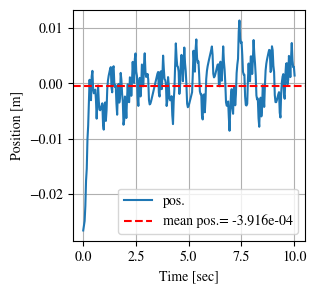

In [57]:
from scipy.interpolate import make_interp_spline, BSpline

time_position = np.linspace(start = 0, stop = len(position)* dt,num=len(position))##############################################
#time_position , position
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
power_smooth = spl(xnew)
font = {'size': 10}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(3)
f.set_figheight(3)
plt.plot(xnew, power_smooth, label="pos.")
plt.axhline(y=power_smooth.mean(), color='r', linestyle='--', label=f'mean pos.= {power_smooth.mean():.3e}')
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Position [m]')
plt.legend()
plt.show()

In [58]:
print(len(position))


501


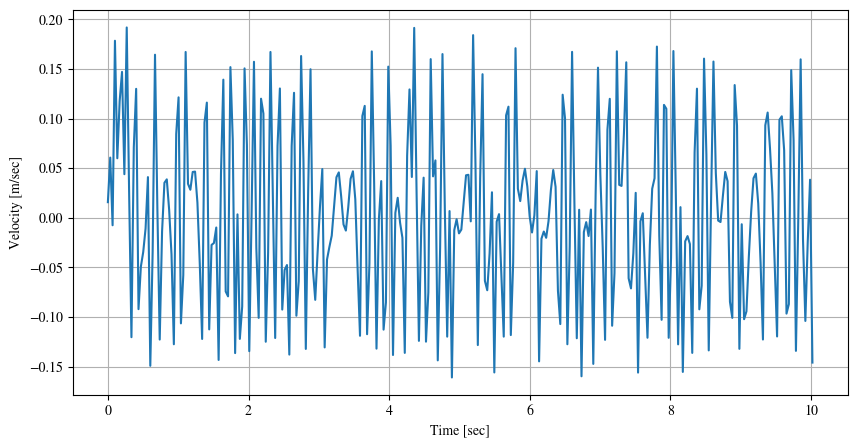

In [59]:
from scipy.interpolate import make_interp_spline, BSpline

time_velocity = np.linspace(start = 0, stop = len(velocity)* dt,num=len(velocity))
#time_velocity , velocity
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_velocity[-1] , 300)

spl = make_interp_spline(time_velocity, velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Velocity [m/sec]')
plt.show()

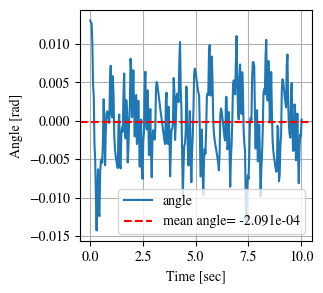

In [60]:
from scipy.interpolate import make_interp_spline, BSpline

time_angle = np.linspace(start = 0, stop = len(angle)* dt,num=len(angle))
#time_angle , angle
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angle[-1] , 300)

spl = make_interp_spline(time_angle,angle, k=3)  # type: BSpline
power_smooth = spl(xnew)
font = {'size': 10}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(3)
f.set_figheight(3)
plt.plot(xnew, power_smooth, label="angle")
plt.axhline(y=power_smooth.mean(), color='r', linestyle='--', label=f'mean angle= {power_smooth.mean():.3e}')
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angle [rad]')
plt.legend()
plt.show()

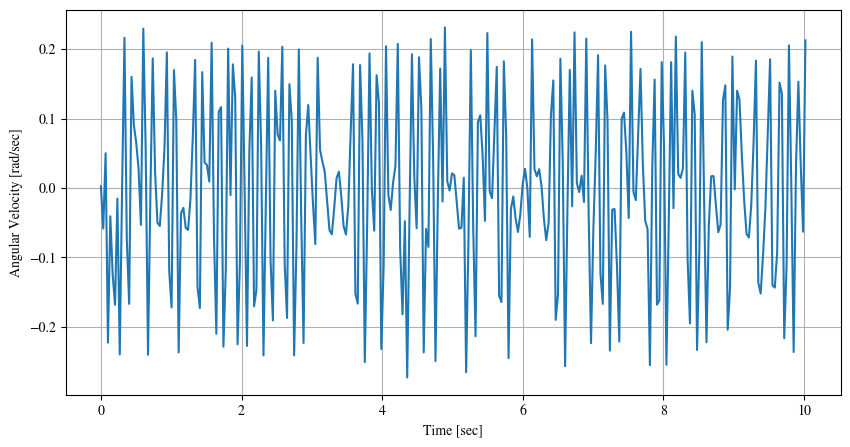

In [61]:
from scipy.interpolate import make_interp_spline, BSpline

time_angular_velocity = np.linspace(start = 0, stop = len(angular_velocity)* dt,num=len(angular_velocity))
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_angular_velocity[-1] , 300)

spl = make_interp_spline(time_angular_velocity, angular_velocity, k=3)  # type: BSpline
power_smooth = spl(xnew)
f = plt.figure()
f.set_figwidth(10)
f.set_figheight(5)
plt.plot(xnew, power_smooth)
plt.grid()
plt.xlabel('Time [sec]')
plt.ylabel('Angular Velocity [rad/sec]')
plt.show()

In [62]:
# 300 represents number of points to make between T.min and T.max
xnew = np.linspace(0, time_position[-1] , 300)

spl = make_interp_spline(time_position, position, k=3)  # type: BSpline
norm_pos = spl(xnew)/0.1#2.4

spl = make_interp_spline(time_position,angle, k=3)  # type: BSpline
norm_angle = spl(xnew)/0.2095#/0.2095#*(180/np.pi)/12

#label = "Norm Pos",color="blue",linewidth = 1.5), ':', label = "Norm Angle",color="red",linewidth = 4)


/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2170: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  result = self._expression.parseString(s)
/usr/local/lib/python3.12/dist-packages/pyparsing/util.py:466: PyparsingDeprecationWarning: 'parseAll' argument is deprecated, use 'parse_all'
  return fn(self, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/matplotlib/_mathtext.py:2178: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  ParserElement.resetCache()


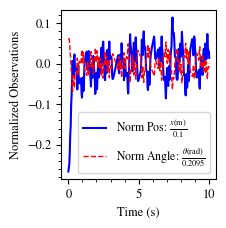

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [63]:
font = {'size': 9}
plt.rc('font', **font)
f = plt.figure()
f.set_figwidth(2.0)
f.set_figheight(2.2)
#plt.rc('text.latex', preamble=r'\usepackage{amsmath}')

plt.plot(xnew, norm_pos,label = r"Norm Pos: $\frac{x(\text{m})}{0.1}$",color="blue",linewidth = 1.5)
plt.plot(xnew, norm_angle,'--', label = r"Norm Angle: $\frac{\theta(\text{rad})}{0.2095}$",color="red",linewidth = 1)

#plt.grid()
#plt.ylim((-9,5))
plt.minorticks_on()
plt.xlabel('Time (s)')
plt.ylabel('Normalized Observations')
plt.legend(fontsize=8.5)
plt.savefig(path+"Cartpole_Obs_vs_Time.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [64]:
print(f"pos:   mean={(norm_pos*0.1).mean():.2e}[m]; std={(norm_pos*0.1).std():.2e}[m]")
print(f"angle: mean={(norm_angle*0.2095).mean():.2e}[rad]; std={(norm_angle*0.2095).std():.2e}[rad]")
print(f"angle: mean={(norm_angle*12).mean():.2e}[deg]; std={(norm_angle*12).std():.2e}[deg]")

pos:   mean=-3.92e-04[m]; std=4.88e-03[m]
angle: mean=-2.09e-04[rad]; std=4.89e-03[rad]
angle: mean=-1.20e-02[deg]; std=2.80e-01[deg]
